<a href="https://colab.research.google.com/github/hawa1983/MG-628/blob/main/Week8_Business_Inferential_Statistics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 8 Assignment: Inferential Statistics and Decision-Making with Python
### Business (MBA) — E-Commerce Onboarding

**Course:** MG628 — Data Analysis for Managerial Decision-Making
**Scenario:** Optimizing E-Commerce Conversions: Premium Support vs. Standard Self-Service (TechFlow)
**Dataset:** `business_conversion_data.csv`

---
**How this notebook works:**
- Every **code cell** is preceded by a **text cell** that explains, in plain language, *what* the code does, *why* we're doing it, and *how* to read the results.
- Inside each code cell, every line (or small group of lines) has a `#` comment explaining what that line does.
- This notebook is written for students who are **new to Python** — if a line of code looks unfamiliar, read the comment directly above or beside it before moving on.
- Wherever you see **`# TODO (your interpretation):`**, that is where YOU write your written interpretation in your own words. Replace the placeholder text with your analysis.

---
### Context
You are a Business Analyst for **TechFlow**, a SaaS company. The Marketing Director piloted a **"Premium Onboarding"** program (Treatment), where new users receive a 1-on-1 video call with a consultant (cost: ~$50/customer). The Control Group receives the standard automated email welcome series.

### Key Business/Policy Question
Considering the cost of hiring consultants for 1-on-1 calls (~$50 per customer), does the increase in Monthly Spend justify expanding the program to all new customers?


## Step 0 — Setup: Importing Our Tools
> **Purpose of this cell:** Load every Python library we will need for the ENTIRE notebook, one time, at the top.
> **Methodology:** We import five libraries that work together: `pandas` for loading and manipulating tabular data, `numpy` for numerical calculations, `matplotlib` and `seaborn` for charts, `scipy.stats` for hypothesis tests, and `statsmodels` for regression.

### Why do this first?
Think of imports like getting tools out of a toolbox before you start a project. Python doesn't automatically know how to do statistics or draw charts — those abilities live in separate "libraries" (collections of pre-written code) that we have to load explicitly. We do this once, in the very first code cell, so every other cell in the notebook can use these tools without re-loading them.

Each library is given a short **nickname** (an "alias") using the `as` keyword, so we don't have to type the full name every time:
- `pandas` → `pd`
- `numpy` → `np`
- `matplotlib.pyplot` → `plt`
- `seaborn` → `sns`


In [ ]:
# Import pandas: the main library for loading, viewing, and manipulating tables of data (called "DataFrames")
import pandas as pd

# Import numpy: provides fast math operations (averages, square roots, etc.) on arrays of numbers
import numpy as np

# Import matplotlib's plotting module: lets us draw charts like histograms and box plots
import matplotlib.pyplot as plt

# Import seaborn: builds on matplotlib to make statistical charts look nicer with less code
import seaborn as sns

# Import the "stats" toolbox from scipy: this gives us t-tests, confidence interval tools, etc.
from scipy import stats

# Import statsmodels' "api" module under the nickname "sm": this is our regression toolbox
import statsmodels.api as sm

# This line tells matplotlib to display charts directly inside the notebook output (not in a separate window)
%matplotlib inline

# A friendly confirmation message so we know the cell ran successfully
print("All libraries imported successfully. Ready to begin!")


All libraries imported successfully. Ready to begin!


## Task 1 — Load and Explore the Data (10 points)
> **Purpose of this cell:** Load `business_conversion_data.csv` into a pandas DataFrame (a table, like a spreadsheet) and run three quick checks to confirm the data is complete and looks the way we expect.
> **Methodology:** We use `pd.read_csv()` to load the file, then call three "exploration" methods — `.head()`, `.info()`, and `.describe()` — that are the standard first step of ANY data analysis project, in any field.

### What each exploration method tells us
- **`df.head(10)`** — shows the first 10 rows of the table, so we can visually confirm the columns look correct (right names, right kinds of values).
- **`df.info()`** — shows the number of rows, the data type of each column (e.g., whole numbers, decimals, or text), and whether any values are missing.
- **`df.describe()`** — calculates quick summary statistics (count, mean, min, max, etc.) for every numeric column, giving us a "bird's-eye view" of the data.

### Our Dataset's Columns
| Column | Type | Description |
|---|---|---|
| `Customer_ID` | Integer | Unique ID for each customer (1-300) |
| `Group` | Text | "Control" (automated email) or "Treatment" (1-on-1 call) |
| `Satisfaction_Score` | Decimal | Feedback score after first 30 days (1.0-10.0) |
| `Monthly_Spend` | Decimal | Dollar amount spent on the platform in month 2 (USD) |

We expect **300 rows total** (150 Control + 150 Treatment) and **zero missing values**.


In [ ]:
# Load the CSV file into a pandas DataFrame called "df" (short for "DataFrame")
# A DataFrame is just a table with rows and columns, similar to an Excel spreadsheet
df = pd.read_csv('business_conversion_data.csv')

# Display the first 10 rows so we can visually inspect the data
# .head(10) means "give me the top 10 rows"
print("===== FIRST 10 ROWS =====")
print(df.head(10))

# Display structural information: column names, data types, and non-null (non-missing) counts
# This is how we confirm there are 300 rows and NO missing values
print("\n===== DATAFRAME INFO =====")
print(df.info())

# Display summary statistics (count, mean, std, min, 25%, 50%, 75%, max) for every numeric column
# This gives us a first impression of typical values and ranges
print("\n===== DESCRIPTIVE STATISTICS =====")
print(df.describe())


===== FIRST 10 ROWS =====
   Customer_ID      Group  Satisfaction_Score  Monthly_Spend
0          204  Treatment                 9.4         239.78
1          267  Treatment                10.0         184.05
2          153  Treatment                 6.8         162.06
3           10    Control                 7.5         157.09
4          234  Treatment                 6.8         157.06
5          227  Treatment                 7.9         162.76
6          197  Treatment                 6.5         156.18
7          110    Control                 6.4         158.35
8            6    Control                 6.1         144.11
9          176  Treatment                 9.0         214.39

===== DATAFRAME INFO =====
<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Customer_ID         300 non-null    int64  
 1   Group               300 non-nu

### Written Interpretation — Task 1
> **Purpose of this cell:** This is a TEXT cell (not code) where you write your interpretation in plain English.

**Instructions:** In 2-3 sentences, describe what each column represents and confirm the data quality (300 rows, no missing values).

---

`# TODO (your interpretation):`

*Example starting point: "This dataset contains 300 customers, split evenly into a Control group and a Treatment group (automated email vs. a 1-on-1 Premium Onboarding call). The Satisfaction_Score column ranges from 1 to 10 and represents ___, while Monthly_Spend represents ___ in US dollars. The `.info()` output confirms there are 300 non-null entries in every column, so the dataset is complete and ready for analysis."*

Replace this with your own words once you've run the cell above and looked at the actual output.


## Task 2 — Summary Statistics by Group (15 points)
> **Purpose of this cell:** Calculate the average (mean) and standard deviation for both Satisfaction_Score and Monthly_Spend, separately for the Control group and the Treatment group.
> **Methodology:** We use a pandas pattern called **"group, then aggregate"**: first we split the 300 rows into two piles based on the `Group` column (Control vs. Treatment), then we calculate statistics for each pile separately.

### New Concepts in This Cell
- **`.groupby('Group')`** — splits the DataFrame into separate groups based on the values in the `Group` column. After this, pandas treats "Control" and "Treatment" as two separate mini-tables.
- **`.agg({...})`** — short for "aggregate." This tells pandas which calculations to run on which columns. We ask for `'mean'` (the average) and `'std'` (the standard deviation, which measures how spread out the values are).
- **`.round(2)`** — rounds every number in the result to 2 decimal places, so dollar amounts look like normal currency (e.g., 146.51 instead of 146.50999999).

### Why does this matter?
This table is our FIRST LOOK at whether Treatment looks any different from Control. A standard deviation tells us how much individual customers vary around the average — a SMALL standard deviation means most customers are close to the average; a LARGE one means there's a lot of variation.


In [ ]:
# Group the DataFrame by the 'Group' column (this creates two groups: 'Control' and 'Treatment')
# Then, for each group, calculate the mean and standard deviation ('std') of two columns
summary_stats = df.groupby('Group').agg({
    'Satisfaction_Score': ['mean', 'std'],   # average and spread of the attitudinal score
    'Monthly_Spend': ['mean', 'std']  # average and spread of the dollar outcome
}).round(2)  # round every number to 2 decimal places for readability

# Display the resulting summary table
print(summary_stats)


          Satisfaction_Score       Monthly_Spend       
                        mean   std          mean    std
Group                                                  
Control                 6.35  1.67        146.51  33.81
Treatment               7.82  1.37        199.97  31.22


### Visualizing Task 2 — Group Comparison Bar Charts
> **Purpose of this cell:** Turn the numbers in the summary table above into a picture, so we can SEE the gap between Control and Treatment at a glance.
> **Methodology:** We draw two side-by-side bar charts — one for Satisfaction Score, one for Monthly Spend — with one bar per group. We also add **error bars** showing +/- 1 standard deviation, so we can see not just the average but how spread out each group's values are.

### New Concepts in This Cell
- **`plt.bar(x, height, yerr=...)`** — draws a bar for each group. `height` sets how tall each bar is (the mean); `yerr` adds a small vertical line ("error bar") on top of each bar showing the standard deviation.
- **`plt.subplot(1, 2, n)`** — same idea as Task 6: place chart number `n` into a 1-row, 2-column grid.
- **Color choice:** We use the SAME two colors for Control and Treatment in every chart in this notebook, so it's easy to visually track each group across multiple charts.


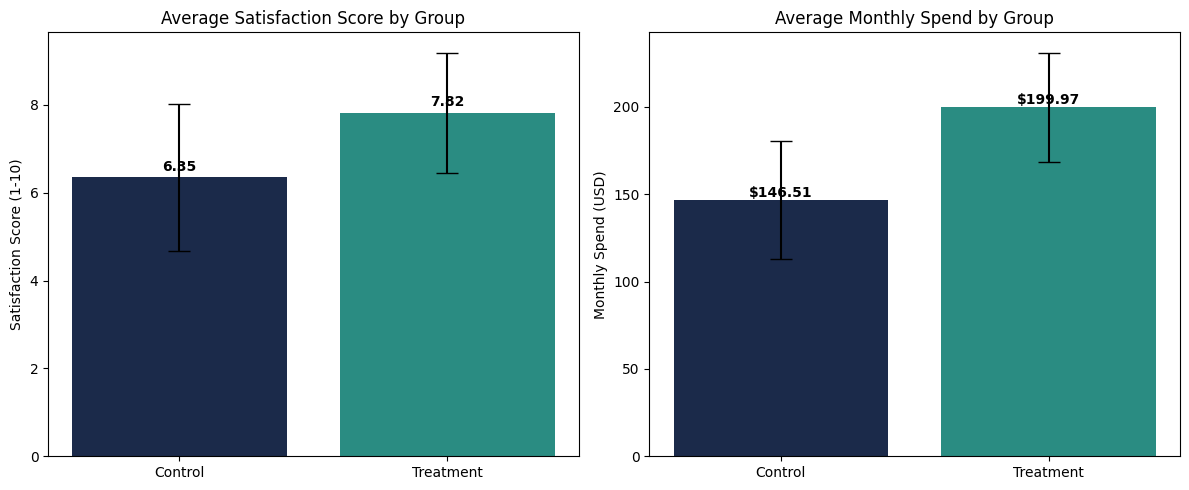

In [ ]:
# Define one color for Control and one for Treatment -- we'll reuse these colors in every chart
group_colors = ['#1B2A4A', '#2A8C82']  # navy = Control, teal = Treatment

# Pull the mean and standard deviation for each group out of our summary_stats table
score_means = summary_stats[('Satisfaction_Score', 'mean')]
score_stds  = summary_stats[('Satisfaction_Score', 'std')]
outcome_means = summary_stats[('Monthly_Spend', 'mean')]
outcome_stds  = summary_stats[('Monthly_Spend', 'std')]

# Create a blank figure 12 inches wide and 5 inches tall
plt.figure(figsize=(12, 5))

# --- LEFT CHART: Satisfaction Score by group ---
plt.subplot(1, 2, 1)
# Draw one bar per group; yerr adds error bars showing +/- 1 standard deviation
plt.bar(score_means.index, score_means.values, yerr=score_stds.values, capsize=8, color=group_colors)
plt.ylabel('Satisfaction Score (1-10)')   # label the y-axis
plt.title('Average Satisfaction Score by Group')  # title for this chart
# Add the exact average value as text above each bar, rounded to 2 decimals
for i, v in enumerate(score_means.values):
    plt.text(i, v + 0.15, f"{v:.2f}", ha='center', fontweight='bold')

# --- RIGHT CHART: Monthly Spend by group ---
plt.subplot(1, 2, 2)
plt.bar(outcome_means.index, outcome_means.values, yerr=outcome_stds.values, capsize=8, color=group_colors)
plt.ylabel('Monthly Spend (USD)')
plt.title('Average Monthly Spend by Group')
for i, v in enumerate(outcome_means.values):
    plt.text(i, v + (outcome_stds.max() * 0.05), f"${v:,.2f}", ha='center', fontweight='bold')

# Adjust spacing so nothing overlaps, then display both charts
plt.tight_layout()
plt.show()


### Written Interpretation — Task 2
> **Purpose of this cell:** Compare the two groups in plain English and calculate the DIFFERENCE between them.

**Instructions:** In 3-4 sentences, address:
1. Compare the satisfaction scores between groups.
2. Compare the monthly spending between groups.
3. Calculate the difference (Treatment minus Control) for Monthly_Spend.
4. Briefly interpret what this means for the business.

---

`# TODO (your interpretation):`

*Hint: To calculate the difference yourself, you can add a small code cell below with something like:*
```python
diff = summary_stats.loc['Treatment', ('Monthly_Spend', 'mean')] - summary_stats.loc['Control', ('Monthly_Spend', 'mean')]
print(f"Difference: {diff:.2f}")
```


## Task 3 — Two-Sample T-Test for Satisfaction Score (15 points)
> **Purpose of this cell:** Test whether the difference in Satisfaction Score we saw in Task 2 is STATISTICALLY SIGNIFICANT — that is, real and reliable, rather than something that could have happened by random chance.
> **Methodology:** We run an **independent two-sample t-test**, which compares the means of two separate, unrelated groups (our 150 Control customers vs. our 150 Treatment customers) and tells us how likely it is we'd see a gap this large if there were truly NO difference between the groups.

### New Concepts in This Cell
- **Boolean filtering** (`df['Group'] == 'Control'`) — this creates a column of `True`/`False` values, one per row, depending on whether that row's Group is "Control." When we put this inside `df[ ... ]`, pandas keeps only the rows where the condition is `True`.
- **`stats.ttest_ind()`** — runs the t-test and returns TWO numbers at once: the **t-statistic** and the **p-value**. We "unpack" both into two variables in one line.
- **f-strings** (`f"...{variable:.4f}"`) — a way to insert a variable's value into a piece of text. The `:.4f` means "show this number with 4 digits after the decimal point."

### How to Read the Result
- **T-statistic**: roughly speaking, "how many standard errors apart are the two group means?" Larger (in absolute value) means a bigger gap relative to natural variation.
- **P-value**: the probability of seeing a gap this large if the two groups were truly identical. If p < 0.05, we call the result **statistically significant**.


In [ ]:
# Create a Series (a single column of data) containing only the Control group's scores
# df['Group'] == 'Control' creates a True/False filter; df[filter] keeps only the True rows
control_score = df[df['Group'] == 'Control']['Satisfaction_Score']

# Same idea, but for the Treatment group
treatment_score = df[df['Group'] == 'Treatment']['Satisfaction_Score']

# Run the independent two-sample t-test on the two groups
# This single function returns TWO values: the t-statistic and the p-value
t_stat, p_value = stats.ttest_ind(control_score, treatment_score)

# Print the t-statistic, formatted to 4 decimal places
print(f"T-statistic: {t_stat:.4f}")

# Print the p-value, formatted to 4 decimal places
print(f"P-value: {p_value:.4f}")

# Compare the p-value to our significance threshold of 0.05
# If p_value is smaller than 0.05, the result is "statistically significant"
if p_value < 0.05:
    print("Result: SIGNIFICANT")   # We reject the null hypothesis
else:
    print("Result: NOT SIGNIFICANT")  # We fail to reject the null hypothesis


T-statistic: -8.3788
P-value: 0.0000
Result: SIGNIFICANT


### Written Interpretation — Task 3
> **Purpose of this cell:** Translate the statistical result above into a plain-language conclusion about Satisfaction Score.

**Instructions:** Write 3-4 sentences addressing ALL of the following:
- **Hypothesis decision:** Do you reject or fail to reject the null hypothesis? (Compare your p-value to alpha = 0.05)
- **Business meaning:** What does this result tell you about the Premium Onboarding program vs. automated emails?
- **Statistical significance:** Is the difference statistically significant? What does that mean — is it likely due to chance, or a real effect?
- **Practical significance:** How large is the actual difference, in points on the 1-10 scale?

---

`# TODO (your interpretation):`


## Task 4 — 95% Confidence Intervals for Monthly Spend (15 points)
> **Purpose of this cell:** Calculate a 95% confidence interval (CI) for the average Monthly Spend in BOTH the Control group and the Treatment group.
> **Methodology:** We write a small reusable **function** called `confidence_interval_95()` that takes a column of numbers and returns three values: the mean, the lower bound of the CI, and the upper bound of the CI. We then call this function twice — once per group.

### New Concepts in This Cell
- **Defining a function** (`def confidence_interval_95(data):`) — a function is a reusable "recipe." We define it once, then can call it as many times as we want with different inputs (`data`).
- **`stats.sem(data)`** — "sem" stands for **S**tandard **E**rror of the **M**ean. This is automatically calculated for us — no manual formula needed.
- **`t_dist.ppf(0.975, n-1)`** — finds the "critical value" from the t-distribution needed for a 95% confidence interval (we use 0.975 because 95% confidence leaves 2.5% in each tail, and 1 - 0.025 = 0.975). `n-1` is the "degrees of freedom."
- **`return mean, mean - margin, mean + margin`** — a function can return MULTIPLE values at once. Here we return the mean, the lower bound, and the upper bound, all in one go.

### How to Read the Result
A 95% confidence interval is a RANGE. If we say "Treatment: $199.97 [$194.93, $205.01]", that means: **we are 95% confident the TRUE average Monthly Spend for ALL customers like these — not just our 300 — falls between $194.93 and $205.01.**


In [ ]:
# Import the t-distribution functions under the nickname "t_dist"
# (we use a different name than "stats.t" just to keep things readable)
from scipy.stats import t as t_dist

# Define a reusable function that calculates a 95% confidence interval for any column of numbers
def confidence_interval_95(data):
    n = len(data)                                  # n = the number of observations (e.g., 150)
    mean = np.mean(data)                           # mean = the average value
    std_err = stats.sem(data)                      # std_err = the standard error of the mean (built-in function)
    margin = std_err * t_dist.ppf(0.975, n - 1)    # margin = how far the interval extends above/below the mean
    return mean, mean - margin, mean + margin      # return three values: mean, lower bound, upper bound

# Create a Series containing only the Control group's Monthly Spend values
control_outcome = df[df['Group'] == 'Control']['Monthly_Spend']

# Create a Series containing only the Treatment group's Monthly Spend values
treatment_outcome = df[df['Group'] == 'Treatment']['Monthly_Spend']

# Call our function on the Control group; this returns 3 values we "unpack" into 3 variables
mean_c, lower_c, upper_c = confidence_interval_95(control_outcome)

# Call our function on the Treatment group, same idea
mean_t, lower_t, upper_t = confidence_interval_95(treatment_outcome)

# Print the Control group's results, formatted as dollar amounts with 2 decimal places
print(f"Control:   Mean = ${mean_c:.2f}   95% CI = [${lower_c:.2f}, ${upper_c:.2f}]")

# Print the Treatment group's results
print(f"Treatment: Mean = ${mean_t:.2f}   95% CI = [${lower_t:.2f}, ${upper_t:.2f}]")


Control:   Mean = $146.51   95% CI = [$141.06, $151.97]
Treatment: Mean = $199.97   95% CI = [$194.93, $205.01]


### Visualizing Task 4 — Confidence Interval Plot
> **Purpose of this cell:** Draw a picture of the two confidence intervals so we can visually check whether they OVERLAP.
> **Methodology:** We plot each group's mean as a dot, with a vertical line through it showing the lower and upper bounds of its 95% confidence interval. If the two vertical lines do NOT touch, the intervals don't overlap.

### New Concepts in This Cell
- **`plt.errorbar(x, y, yerr=..., fmt='o', capsize=...)`** — plots a single point at `(x, y)` with a vertical error bar extending `yerr` above and below it. Here, `y` is the group mean and `yerr` is the margin of error (the distance from the mean to each bound of the CI).
- **`plt.axhline(y=..., linestyle='--')`** — draws a horizontal dashed reference line across the whole chart (we use this in the Public Admin notebook for the self-sufficiency wage benchmark, and in general it's a useful way to mark an important threshold).


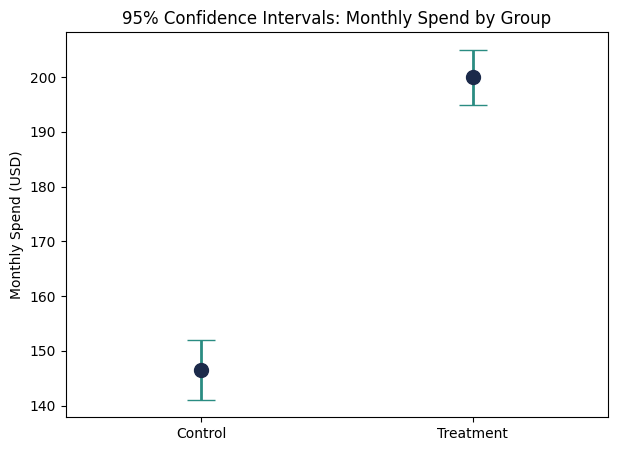

In [ ]:
# x-positions for our two groups on the chart (just 0 and 1)
x_positions = [0, 1]
group_names = ['Control', 'Treatment']

# The mean for each group (calculated earlier in Task 4)
means = [mean_c, mean_t]

# The "margin" for each group = how far the CI extends above/below the mean
# (upper bound - mean) gives us this margin directly
margins = [upper_c - mean_c, upper_t - mean_t]

# Create a figure 7 inches wide and 5 inches tall
plt.figure(figsize=(7, 5))

# Plot each group's mean as a dot, with a vertical error bar showing its 95% CI
# fmt='o' means "draw a circular marker"; capsize adds small horizontal caps to the error bar ends
plt.errorbar(x_positions, means, yerr=margins, fmt='o', capsize=10, markersize=10,
             color='#1B2A4A', ecolor='#2A8C82', elinewidth=2)

# Label each x-position with the group name instead of 0 and 1
plt.xticks(x_positions, group_names)

# Add some padding on the left/right so the points aren't squished against the edges
plt.xlim(-0.5, 1.5)

# Label the y-axis and add a title
plt.ylabel('Monthly Spend (USD)')
plt.title('95% Confidence Intervals: Monthly Spend by Group')

# (No additional reference line needed for this scenario)

# Display the chart
plt.show()


### Written Interpretation — Task 4
> **Purpose of this cell:** Explain what these two confidence intervals tell us, and whether they OVERLAP.

**Instructions:** Write 3-4 sentences addressing:
- **Control CI meaning:** What can you say about the TRUE average Monthly Spend for all Control customers?
- **Treatment CI meaning:** What can you say about the TRUE average Monthly Spend for all Treatment customers?
- **Overlap analysis:** Do the two intervals overlap (share any values)? What does that tell you about whether the difference between groups is real?
- **Practical business insight:** Calculate and state the approximate difference between the two group means. What does this mean in dollars per customer?

---

`# TODO (your interpretation):`


## Task 5 — Regression Analysis (20 points)
> **Purpose of this cell:** Build a regression model that predicts Monthly Spend using TWO predictors at once: Satisfaction Score AND whether the customer was in the Treatment group. This lets us ask "how much does each factor matter, holding the other one constant?"
> **Methodology:** We create a new **dummy variable** called `Group_Treatment` (1 if Treatment, 0 if Control), then fit an **Ordinary Least Squares (OLS)** regression using `statsmodels`.

### New Concepts in This Cell
- **Dummy variable**: `(df['Group'] == 'Treatment').astype(int)` first creates a column of `True`/`False`, then `.astype(int)` converts `True` → `1` and `False` → `0`. Now "Group" is represented as a NUMBER the regression model can use.
- **`X` and `y`**: by statistical convention, `X` (capital letter) holds our PREDICTOR (independent) variables, and `y` (lowercase) holds the OUTCOME (dependent) variable we're trying to predict.
- **`sm.add_constant(X)`** — adds a column of 1s to `X`. This is required by `statsmodels` so the model can calculate an "intercept" (a baseline value).
- **`sm.OLS(y, X).fit()`** — "OLS" stands for Ordinary Least Squares, the standard method for linear regression. `.fit()` actually runs the calculation.
- **`model.summary()`** — prints a big table with everything we need: coefficients, p-values, R-squared, and more.

### How to Read the Result
- A **positive** `Satisfaction_Score` coefficient means higher satisfaction is associated with HIGHER spending.
- A **positive** `Group_Treatment` coefficient means being in the Treatment group is associated with HIGHER spending, **even after** accounting for satisfaction differences.
- **R-squared** tells us what percentage of the variation in Monthly Spend is explained by our two predictors combined (closer to 1.0 = better fit).


In [ ]:
# Create a new column called 'Group_Treatment'
# (df['Group'] == 'Treatment') gives True/False for each row
# .astype(int) converts True -> 1 and False -> 0
df['Group_Treatment'] = (df['Group'] == 'Treatment').astype(int)

# X holds our predictor (independent) variables: the attitudinal score AND the treatment flag
X = df[['Satisfaction_Score', 'Group_Treatment']]

# y holds the outcome (dependent) variable we are trying to predict
y = df['Monthly_Spend']

# Add a constant (intercept) column to X -- required by statsmodels for OLS regression
X = sm.add_constant(X)

# Fit an Ordinary Least Squares (OLS) regression model: this finds the best-fitting line
model = sm.OLS(y, X).fit()

# Print the full regression results table: coefficients, p-values, R-squared, and more
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:          Monthly_Spend   R-squared:                       0.676
Model:                            OLS   Adj. R-squared:                  0.673
Method:                 Least Squares   F-statistic:                     309.2
Date:                Fri, 12 Jun 2026   Prob (F-statistic):           2.53e-73
Time:                        10:35:06   Log-Likelihood:                -1378.3
No. Observations:                 300   AIC:                             2763.
Df Residuals:                     297   BIC:                             2774.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 55.3014      6

### Helper Cell — Pulling Out the Key Numbers
> **Purpose of this cell:** The full `model.summary()` table above is dense. This cell pulls out just the numbers we need for our interpretation and prints them in a clean, simple format.
> **Methodology:** `model.params` is a list of the coefficients (one per predictor, plus the intercept); `model.pvalues` is the matching list of p-values; `model.rsquared` is a single number. We access individual values using their column NAME inside square brackets.


In [ ]:
# model.params holds the coefficient for each term; we access it by name in square brackets
const_coef = model.params['const']                       # the intercept
score_coef = model.params['Satisfaction_Score']           # coefficient for Satisfaction Score
treat_coef = model.params['Group_Treatment']              # coefficient for being in Treatment

# model.pvalues holds the p-value for each term, same naming pattern
score_pval = model.pvalues['Satisfaction_Score']
treat_pval = model.pvalues['Group_Treatment']

# model.rsquared is a single number representing the overall fit of the model (0 to 1)
r_squared = model.rsquared

# Print everything in an easy-to-read format
print(f"R-squared = {r_squared:.3f}  (the model explains about {r_squared*100:.1f}% of the variation)")
print(f"Satisfaction_Score: beta = {score_coef:.2f}, p = {score_pval:.4f}")
print(f"Group_Treatment: beta = {treat_coef:.2f}, p = {treat_pval:.4f}")


R-squared = 0.676  (the model explains about 67.6% of the variation)
Satisfaction_Score: beta = 14.37, p = 0.0000
Group_Treatment: beta = 32.21, p = 0.0000


### Visualizing Task 5 — Regression Scatter Plot with Fitted Lines
> **Purpose of this cell:** Draw a scatter plot of Satisfaction Score (x-axis) vs. Monthly Spend (y-axis), with each customer shown as a single dot, colored by group. Then overlay the regression model's predicted line for each group.
> **Methodology:** Because our regression includes BOTH Satisfaction_Score and `Group_Treatment` as predictors, the model effectively draws TWO parallel lines — one for Control (`Group_Treatment = 0`) and one for Treatment (`Group_Treatment = 1`). The VERTICAL DISTANCE between these two lines at any point is exactly the `Group_Treatment` coefficient we calculated above.

### New Concepts in This Cell
- **`plt.scatter(x, y, c=color, label=..., alpha=...)`** — plots one dot per row of data. `alpha` makes dots semi-transparent so we can see when many dots overlap.
- **`np.linspace(start, stop, n)`** — creates `n` evenly spaced numbers between `start` and `stop`. We use this to generate a smooth x-axis range for drawing our line.
- **Predicting by hand:** Once we have our model's coefficients, the predicted value is simply `intercept + (score_coef * x) + (treat_coef * group_flag)`. We calculate this manually for each line.


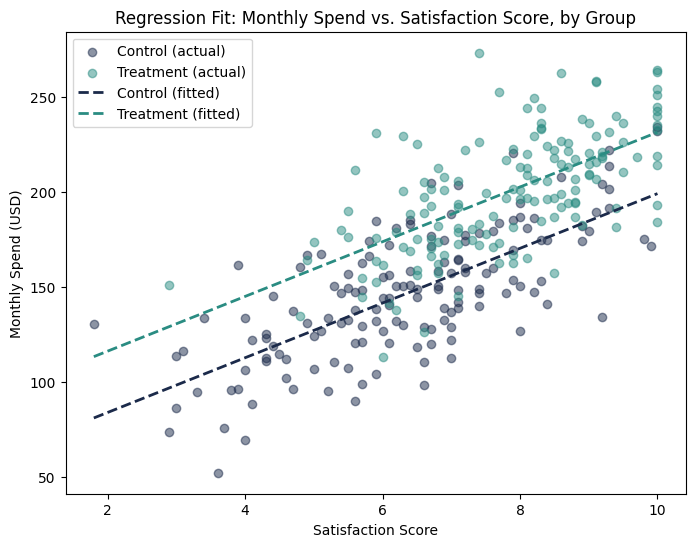

In [ ]:
# Create a figure 8 inches wide and 6 inches tall
plt.figure(figsize=(8, 6))

# Plot Control group customers as navy dots
plt.scatter(control_score, control_outcome, color='#1B2A4A', label='Control (actual)', alpha=0.5)

# Plot Treatment group customers as teal dots
plt.scatter(treatment_score, treatment_outcome, color='#2A8C82', label='Treatment (actual)', alpha=0.5)

# Create 50 evenly spaced x-values spanning the full range of Satisfaction_Score
# so we can draw a smooth line across the chart
x_range = np.linspace(df['Satisfaction_Score'].min(), df['Satisfaction_Score'].max(), 50)

# Predicted line for the CONTROL group: Group_Treatment = 0, so that term drops out
control_line = const_coef + score_coef * x_range + treat_coef * 0

# Predicted line for the TREATMENT group: Group_Treatment = 1
treatment_line = const_coef + score_coef * x_range + treat_coef * 1

# Draw both regression lines, using dashed lines so they stand out from the dots
plt.plot(x_range, control_line, color='#1B2A4A', linestyle='--', linewidth=2, label='Control (fitted)')
plt.plot(x_range, treatment_line, color='#2A8C82', linestyle='--', linewidth=2, label='Treatment (fitted)')

# Label the axes and add a title
plt.xlabel('Satisfaction Score')
plt.ylabel('Monthly Spend (USD)')
plt.title('Regression Fit: Monthly Spend vs. Satisfaction Score, by Group')

# Show the legend so we know which color/line style is which
plt.legend()

# Display the chart
plt.show()


### Written Interpretation — Task 5
> **Purpose of this cell:** Explain, in plain language, what the regression results mean for TechFlow's leadership.

**Instructions:** Write 4-5 sentences addressing ALL of the following:
- **Satisfaction_Score coefficient:** What happens to monthly spend when satisfaction increases by 1 point? Is this significant (check p-value)? What does it mean in practical terms?
- **Group_Treatment coefficient:** What is the effect of being in Treatment on monthly spend? Is it significant? Does this effect exist even after accounting for satisfaction differences?
- **R-squared:** What percentage of variance in monthly spend does the model explain? Is this a good fit?
- **Overall conclusion:** Do both variables independently predict spending? What does this tell you about HOW the Premium Onboarding program works?

---

`# TODO (your interpretation):`


## Task 6 — Data Visualizations (15 points)
> **Purpose of this cell:** Create TWO charts that visually compare Satisfaction Score between the Control and Treatment groups: an overlapping histogram and side-by-side box plots.
> **Methodology:** We use `matplotlib`'s `plt.subplot()` to place two charts side-by-side in one figure, then build each chart step by step.

### New Concepts in This Cell
- **`plt.figure(figsize=(14, 5))`** — creates a blank "canvas" for our charts, 14 inches wide and 5 inches tall.
- **`plt.subplot(1, 2, 1)`** — means "this figure has 1 row and 2 columns of charts; draw the next chart in position 1 (left)." `plt.subplot(1, 2, 2)` would mean position 2 (right).
- **`plt.hist(..., alpha=0.6, ...)`** — draws a histogram (a bar chart showing how many values fall into each range). `alpha=0.6` makes the bars 60% opaque (semi-transparent), so when two histograms overlap, you can see BOTH of them.
- **`df.boxplot(column=..., by='Group')`** — automatically creates one box plot PER group. The box shows the middle 50% of the data; the line inside the box is the median; "whiskers" extend to the rest of the data; dots beyond the whiskers are outliers.
- **`plt.legend()`**, **`plt.xlabel()`**, **`plt.ylabel()`**, **`plt.title()`** — these label our chart so anyone looking at it (without reading our code) can understand what it shows.


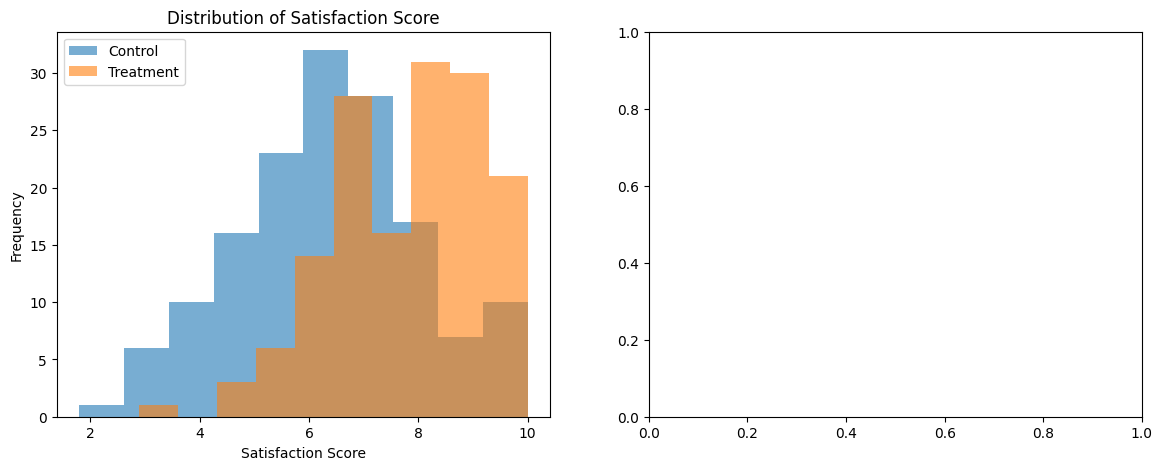

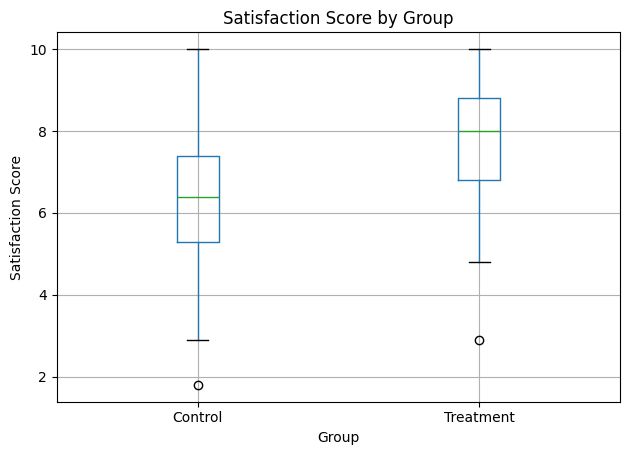

In [ ]:
# Create a blank figure (canvas) that is 14 inches wide and 5 inches tall
plt.figure(figsize=(14, 5))

# --- LEFT CHART: Overlapping Histogram ---

# Tell matplotlib: "1 row, 2 columns of charts; draw the next one in position 1 (left)"
plt.subplot(1, 2, 1)

# Draw a histogram of the Control group's scores
# alpha=0.6 makes the bars semi-transparent; bins=10 splits the 1-10 scale into 10 bars
plt.hist(control_score, alpha=0.6, label='Control', bins=10)

# Draw a histogram of the Treatment group's scores ON TOP of the Control histogram
plt.hist(treatment_score, alpha=0.6, label='Treatment', bins=10)

# Label the x-axis (horizontal)
plt.xlabel('Satisfaction Score')

# Label the y-axis (vertical)
plt.ylabel('Frequency')

# Add a title above this chart
plt.title('Distribution of Satisfaction Score')

# Show the legend so we know which color is Control and which is Treatment
plt.legend()

# --- RIGHT CHART: Side-by-Side Box Plots ---

# Tell matplotlib: "1 row, 2 columns of charts; draw the next one in position 2 (right)"
plt.subplot(1, 2, 2)

# Create side-by-side box plots of the score column, split by the Group column
df.boxplot(column='Satisfaction_Score', by='Group')

# Label the x-axis
plt.xlabel('Group')

# Label the y-axis
plt.ylabel('Satisfaction Score')

# Add a title above this chart
plt.title('Satisfaction Score by Group')

# Remove the automatic "Boxplot grouped by Group" subtitle that pandas adds
plt.suptitle('')

# Automatically adjust spacing so labels and titles don't overlap
plt.tight_layout()

# Display both charts
plt.show()


### Written Interpretation — Task 6
> **Purpose of this cell:** Describe what the two charts above show, in plain English.

**Instructions:**

**Histogram (2-3 sentences):**
- Where are most scores concentrated for each group (low end, middle, or high end of the 1-10 scale)?
- How do the two distributions differ in shape or location?

**Box Plot (2-3 sentences):**
- Which group has the higher median? Approximately what are the median values?
- Which group has a wider box (more variability) vs. a narrower box (more consistency)?
- Are there any outliers? What might they represent?

**Connect to the Business Question:** What do these patterns tell you about the Premium Onboarding program's effect? Does one group consistently show higher satisfaction? Is one group more predictable (less variable)?

---

`# TODO (your interpretation):`


## Task 7 — Business Recommendation Memo (10 points)
> **Purpose of this cell:** This is a TEXT cell (Markdown), not code. Here, you synthesize EVERYTHING from Tasks 1-6 into a professional memo that a non-technical decision-maker could read and act on.
> **Methodology:** Use the Markdown headers below to organize your memo. Replace every `[bracketed placeholder]` with your own numbers and analysis from the cells above. Remember the golden rule from lecture: **translate statistics into plain language** — instead of "we reject the null hypothesis at alpha = 0.05," say "there is less than a 5% chance this result happened by accident."

---

**To:** Marketing Director, TechFlow
**From:** [Your Name]
**Date:** [Date]
**Subject:** Recommendation on Expanding the Premium Onboarding Program

### 1. Executive Summary
`# TODO:` State a clear **YES** or **NO** recommendation in 1-2 sentences, with your primary reason.

### 2. Key Findings
- **Business meaning (Task 3):** T-statistic = [value], p-value = [value]. State whether this is statistically significant.
- **Financial Impact (Task 2):** Control average Monthly Spend = $[value]; Treatment average = $[value]; difference = $[value].
- **Confidence Intervals (Task 4):** Do the 95% CIs overlap? What does this tell you about the reliability of the difference?
- **Regression Results (Task 5):** Satisfaction_Score coefficient = [value] (p = [value]); Group_Treatment coefficient = [value] (p = [value]); R-squared = [value].

### 3. Cost-Benefit Analysis
- **Program cost per customer:** $50.00 (one-time, for the 1-on-1 consultant call)
- **Revenue benefit per customer:** Use your Task 2 difference in Monthly Spend — how much MORE does the Treatment group spend per month?
- **ROI calculation:** Does the monthly revenue increase exceed the $50 one-time cost? `# TODO:` State the break-even: "We spend $50 once and gain $[value] EVERY MONTH."
- **Long-term projection (optional):** If TechFlow gets [N] new customers per year, what's the annual revenue impact?

### 4. Recommendation
**Paragraph 1:** Restate your recommendation (YES/NO) with the primary justification, in an actionable way.

**Paragraph 2:** Support your recommendation with evidence from your statistical findings — address BOTH the attitudinal measure (Satisfaction Score) AND the financial outcome.

**Paragraph 3:** Discuss implementation considerations — acknowledge concerns or limitations, and suggest next steps.

### 5. Considerations & Limitations
- **Assumptions:** Are you assuming this pattern continues over time, and that pilot results will scale up?
- **Selection bias:** Were customers randomly assigned to Control/Treatment, or did they self-select? Could this bias the results?
- **Confounding variables:** Did Treatment customers also receive other promotions or discounts during the pilot period that could explain some of the spending difference?
- **Additional data needed:** Customer retention rates, lifetime value, and churn rates would strengthen this analysis.
- **Risks/challenges:** Will the spending gap persist over time, or could it fade as the novelty of 1-on-1 onboarding wears off? Are there enough consultants to staff Premium Onboarding at full scale?

---
*Remember: every numeric claim above should come from a cell you actually ran. Go back and fill in every `[bracketed placeholder]` with a real number before submitting.*
